In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import (train_test_split, StratifiedKFold, 
                                      cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import accuracy_score

# Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Feature Selection
from sklearn.feature_selection import mutual_info_classif

# Tuning
import optuna

train_path = r'C:\Users\divye\Data_science_projects\spaceship_titanic\data\train.csv'
test_path = r'C:\Users\divye\Data_science_projects\spaceship_titanic\data\test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_df.head(20)
print(train_df.info())

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
print(f"\nTarget distribution:")
print(train_df['Transported'].value_counts(normalize=True))

Train shape: (8693, 14)
Test shape:  (4277, 13)

Target distribution:
True     0.503624
False    0.496376
Name: Transported, dtype: float64


In [ ]:
# ================================
# 🔍 QUICK EDA
# ================================

# Missing values
print("📊 MISSING VALUES:")
print("=" * 40)
missing = pd.concat([
    train_df.isnull().sum(),
    train_df.isnull().mean().mul(100).round(2)
], axis=1, keys=['Count', '%'])
print(missing[missing['Count'] > 0])

# Data types
print(f"\n📊 DATA TYPES:")
print("=" * 40)
print(train_df.dtypes)

# First look
train_df.head()

📊 MISSING VALUES:
              Count     %
HomePlanet      201  2.31
CryoSleep       217  2.50
Cabin           199  2.29
Destination     182  2.09
Age             179  2.06
VIP             203  2.34
RoomService     181  2.08
FoodCourt       183  2.11
ShoppingMall    208  2.39
Spa             183  2.11
VRDeck          188  2.16
Name            200  2.30

📊 DATA TYPES:
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
# ================================
# 🔗 COMBINE (for row-level FE only)
# ================================
train_df['is_train'] = True
test_df['is_train'] = False

# Save target & IDs before combining
target = train_df['Transported'].copy()
test_ids = test_df['PassengerId'].copy()

combined = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)
print(f"Combined shape: {combined.shape}")

Combined shape: (12970, 15)


In [ ]:
# ================================
# ⚙️ FEATURE ENGINEERING (with NaN handling)
# ================================

# 1. Cabin → Deck, CabinNum, Side
combined[['Deck', 'CabinNum', 'Side']] = combined['Cabin'].str.split('/', expand=True)
combined['CabinNum'] = pd.to_numeric(combined['CabinNum'], errors='coerce')
combined['Side'] = combined['Side'].map({'S': 0, 'P': 1})

# 2. PassengerId → Group, PersonInGroup
combined['Group'] = combined['PassengerId'].apply(lambda x: x.split('_')[0]).astype(int)
combined['PersonInGroup'] = combined['PassengerId'].apply(lambda x: x.split('_')[1]).astype(int)

# 3. Name → LastName
combined['LastName'] = combined['Name'].apply(
    lambda x: x.split()[-1] if pd.notnull(x) else 'Unknown'
)

# 4. Spending Features (fill NaN with 0 BEFORE creating features)
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
combined[spend_cols] = combined[spend_cols].fillna(0)

combined['TotalSpend'] = combined[spend_cols].sum(axis=1)
combined['NoSpend'] = (combined['TotalSpend'] == 0).astype(int)
combined['LuxurySpend'] = combined['Spa'] + combined['VRDeck'] + combined['RoomService']
combined['BasicSpend'] = combined['FoodCourt'] + combined['ShoppingMall']

# 5. CryoSleep logic — if CryoSleep, all spending should be 0
combined.loc[combined['CryoSleep'] == True, spend_cols] = 0
combined.loc[combined['CryoSleep'] == True, 'TotalSpend'] = 0


# 6. Age Bins (NaN stays NaN — pipeline handles it later)
combined['AgeBin'] = pd.cut(
    combined['Age'],
    bins=[0, 12, 18, 30, 50, 100],
    labels=['Child', 'Teen', 'Young', 'Adult', 'Senior']
)

# 7. Boolean features
combined['CryoSleep'] = combined['CryoSleep'].astype(float)
combined['VIP'] = combined['VIP'].astype(float)

# ================================
# 📊 Check remaining missing values
# ================================
print("✅ Feature Engineering done!\n")
print("📊 Remaining Missing Values:")
print("=" * 40)
missing = combined.isnull().sum()
print(missing[missing > 0])

✅ Feature Engineering done!

📊 Remaining Missing Values:
HomePlanet      288
CryoSleep       310
Cabin           299
Destination     274
Age             270
VIP             296
Name            294
Transported    4277
Deck            299
CabinNum        299
Side            299
AgeBin          530
dtype: int64


In [ ]:
# ================================
# ✂️ SPLIT BACK
# ================================
train_data = combined[combined['is_train'] == True].copy()
test_data = combined[combined['is_train'] == False].copy()

# Restore target
train_data['Transported'] = target.values

# Drop helper column
train_data = train_data.drop('is_train', axis=1)
test_data = test_data.drop('is_train', axis=1)

print(f"Train: {train_data.shape}")
print(f"Test:  {test_data.shape}")

Train: (8693, 25)
Test:  (4277, 25)


In [ ]:
# ================================
# ⚙️ AGGREGATE FEATURES (Train → Test, NO leakage)
# ================================

# 1. GroupSize — from TRAIN only
group_size = train_data.groupby('Group').size()
train_data['GroupSize'] = train_data['Group'].map(group_size)
test_data['GroupSize'] = test_data['Group'].map(group_size).fillna(1).astype(int)

# 2. IsAlone
train_data['IsAlone'] = (train_data['GroupSize'] == 1).astype(int)
test_data['IsAlone'] = (test_data['GroupSize'] == 1).astype(int)

# 3. FamilySize (same LastName in Group) — from TRAIN only
family_size = train_data.groupby('LastName').size()
train_data['FamilySize'] = train_data['LastName'].map(family_size)
test_data['FamilySize'] = test_data['LastName'].map(family_size).fillna(1).astype(int)

print("✅ Aggregate Features done (no leakage)!")

✅ Aggregate Features done (no leakage)!


In [ ]:
# ================================
# 🧹 PREPARE FINAL DATA
# ================================
drop_cols = ['Transported', 'PassengerId', 'Cabin', 'Name', 
             'LastName', 'Group']

y = train_data['Transported'].astype(int)
X = train_data.drop(columns=[c for c in drop_cols if c in train_data.columns])
X_test = test_data.drop(columns=[c for c in drop_cols if c in test_data.columns])

# Verify columns match
assert list(X.columns) == list(X_test.columns), "❌ Column mismatch!"
print("✅ Columns match!")

# Column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()

print(f"\nFeatures: {X.shape[1]}")
print(f"Numeric:  {len(num_cols)} → {num_cols}")
print(f"Category: {len(cat_cols)} → {cat_cols}")

✅ Columns match!

Features: 22
Numeric:  15 → ['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinNum', 'Side', 'TotalSpend', 'LuxurySpend', 'BasicSpend', 'GroupSize', 'FamilySize']
Category: 4 → ['HomePlanet', 'Destination', 'Deck', 'AgeBin']


In [ ]:
# ================================
# 🔧 PREPROCESSOR
# ================================
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

print("✅ Preprocessor ready!")

✅ Preprocessor ready!


In [ ]:
# ================================
# 📊 BASELINE — All 3 Models
# ================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'XGBoost': XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.05, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=500, max_depth=5, learning_rate=0.05, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=500, depth=5, learning_rate=0.05, random_state=42, verbose=0)
}

print("📊 BASELINE RESULTS:")
print("=" * 50)

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')
    print(f"{name:12s} CV: {scores.mean():.4f} ± {scores.std():.4f}")

📊 BASELINE RESULTS:
XGBoost      CV: 0.8110 ± 0.0060
LightGBM     CV: 0.8088 ± 0.0054
CatBoost     CV: 0.8138 ± 0.0053


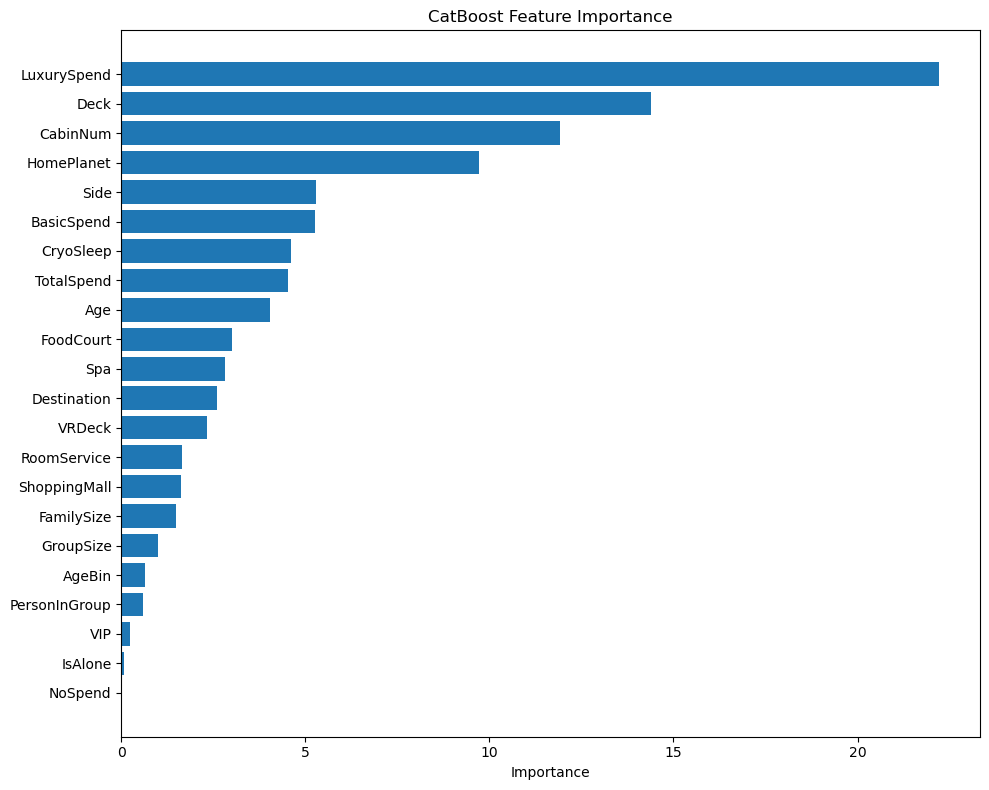

      feature  importance
  LuxurySpend   22.217623
         Deck   14.400356
     CabinNum   11.905845
   HomePlanet    9.711801
         Side    5.298990
   BasicSpend    5.257496
    CryoSleep    4.610556
   TotalSpend    4.534081
          Age    4.030747
    FoodCourt    3.005550
          Spa    2.805977
  Destination    2.608239
       VRDeck    2.332686
  RoomService    1.642840
 ShoppingMall    1.624428
   FamilySize    1.481557
    GroupSize    0.984066
       AgeBin    0.646600
PersonInGroup    0.592772
          VIP    0.226300
      IsAlone    0.081489
      NoSpend    0.000000


In [ ]:
# ================================
# 🔍 FEATURE IMPORTANCE
# ================================
X_temp = X.copy()
for col in X_temp.select_dtypes(include=['object', 'category', 'bool']).columns:
    X_temp[col] = LabelEncoder().fit_transform(X_temp[col].astype(str))
X_temp = X_temp.fillna(-999)

# Quick CatBoost
quick_model = CatBoostClassifier(iterations=500, depth=5, random_state=42, verbose=0)
quick_model.fit(X_temp, y)

# Plot
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': quick_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1])
plt.xlabel('Importance')
plt.title('CatBoost Feature Importance')
plt.tight_layout()
plt.show()

print(feat_imp.to_string(index=False))

In [ ]:
# ================================
# 🎯 OPTUNA — CatBoost
# ================================
def cat_objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1000),
        'depth': trial.suggest_int('depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 0.9),
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_strength': trial.suggest_float('random_strength', 0.1, 2.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_state': 42,
        'verbose': 0
    }
    
    model = CatBoostClassifier(**params)
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')
    return scores.mean()

cat_study = optuna.create_study(direction='maximize')
cat_study.optimize(cat_objective, n_trials=100, show_progress_bar=True)

print(f"\n✅ Best CatBoost CV: {cat_study.best_value:.4f}")
print(f"Best Params: {cat_study.best_params}")

[I 2026-04-29 11:51:04,157] A new study created in memory with name: no-name-dafee323-9e9f-41c1-aa99-da3a815d45c3


  0%|          | 0/100 [00:00<?, ?it/s]

[W 2026-04-29 11:51:10,413] Trial 0 failed with parameters: {'iterations': 991, 'depth': 6, 'learning_rate': 0.01811318380872203, 'l2_leaf_reg': 4.5775707273776405, 'subsample': 0.8510957441303655, 'colsample_bylevel': 0.8683160381106185, 'min_child_samples': 10, 'border_count': 98, 'random_strength': 1.2687388575794143, 'bagging_temperature': 0.9730342554040461} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "c:\Users\divye\anaconda3\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\divye\AppData\Local\Temp\ipykernel_22736\1195335378.py", line 22, in cat_objective
    scores = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\divye\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 515, in cross_val_score
    cv_results

KeyboardInterrupt: 

In [ ]:
# ================================
# 🏆 FINAL MODEL & SUBMISSION
# ================================

# Best CatBoost
final_model = Pipeline([
    ('prep', preprocessor),
    ('model', CatBoostClassifier(**cat_study.best_params, random_state=42, verbose=0))
])

# Final CV check
final_cv = cross_val_score(final_model, X, y, cv=skf, scoring='accuracy')
print(f"🏆 Final CV: {final_cv.mean():.4f} ± {final_cv.std():.4f}")

# Train on ALL data
final_model.fit(X, y)

# Predict test
predictions = final_model.predict(X_test)

# Create submission
submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Transported': predictions.astype(bool)
})

submission.to_csv('data/submission.csv', index=False)

print(f"\n✅ Submission saved!")
print(f"Total predictions: {len(submission)}")
print(f"\nDistribution:")
print(submission['Transported'].value_counts(normalize=True))
submission.head()

🏆 Final CV: 0.8182 ± 0.0037

✅ Submission saved!
Total predictions: 4277

Distribution:
True     0.527473
False    0.472527
Name: Transported, dtype: float64


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


### Another Model: Neural Network 

In [6]:
import sys
!{sys.executable} -m pip install numpy==1.26.4 --force-reinstall --user

  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
transformers 2.1.1 requires sentencepiece, which is not installed.
numba 0.57.0 requires numpy<1.25,>=1.21, but you have numpy 1.26.4 which is incompatible.


In [7]:
import numpy as np
print(np.__version__)

2.4.4
